In [1]:
# Samsung Price Intelligence — Analysis Notebook Code

# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot style
sns.set_theme(style="whitegrid")

In [2]:
# ==============================
# 2. LOAD DATA
# ==============================
file_path = "../data/processed/samsung_features.csv"
df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nPreview:")
print(df.head())

Dataset Shape: (154, 18)

Columns:
['name', 'url', 'brand', 'platform', 'image', 'title_raw', 'scraped_at', 'release_month', 'release_year', 'display_raw', 'chipset_raw', 'battery_raw', 'storage_raw', 'ram_raw', 'series', 'device_age', 'battery_category', 'performance_score']

Preview:
               name                                                url  \
0       Galaxy F70e  https://www.gsmarena.com/samsung_galaxy_f70e_5...   
1        Galaxy A07  https://www.gsmarena.com/samsung_galaxy_a07_5g...   
2  Galaxy Z TriFold  https://www.gsmarena.com/samsung_galaxy_z_trif...   
3        Galaxy M17  https://www.gsmarena.com/samsung_galaxy_m17_5g...   
4        Galaxy F07  https://www.gsmarena.com/samsung_galaxy_f07-14...   

     brand  platform                                              image  \
0  Samsung  GSMArena  https://fdn2.gsmarena.com/vv/bigpic/samsung-ga...   
1  Samsung  GSMArena  https://fdn2.gsmarena.com/vv/bigpic/samsung-ga...   
2  Samsung  GSMArena  https://fdn2.gsmarena

In [3]:
# ==============================
# 3. DATA QUALITY CHECK
# ==============================
print("\nMissing Values:")
print(df.isna().sum())

print("\nData Types:")
print(df.dtypes)

print("\nBasic Statistics:")
print(df.describe())



Missing Values:
name                 0
url                  0
brand                0
platform             0
image                0
title_raw            0
scraped_at           0
release_month        0
release_year         0
display_raw          0
chipset_raw          0
battery_raw          0
storage_raw          0
ram_raw              0
series               0
device_age           0
battery_category     0
performance_score    0
dtype: int64

Data Types:
name                     str
url                      str
brand                    str
platform                 str
image                    str
title_raw                str
scraped_at               str
release_month            str
release_year           int64
display_raw          float64
chipset_raw              str
battery_raw            int64
storage_raw            int64
ram_raw                int64
series                   str
device_age             int64
battery_category         str
performance_score    float64
dtype: object

Basic 

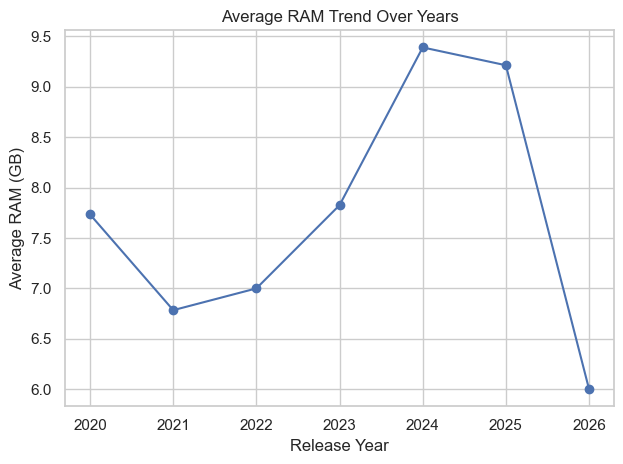

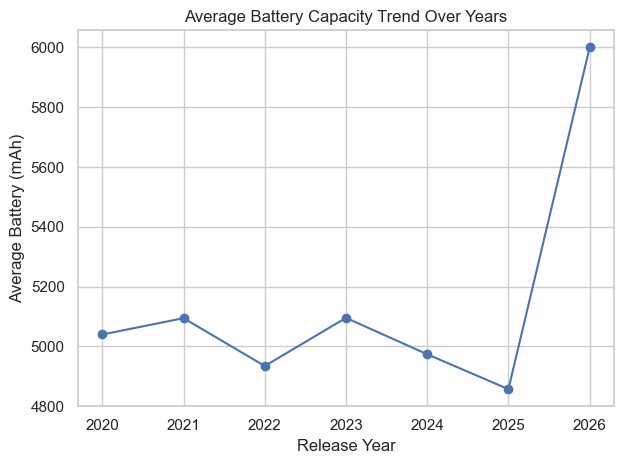

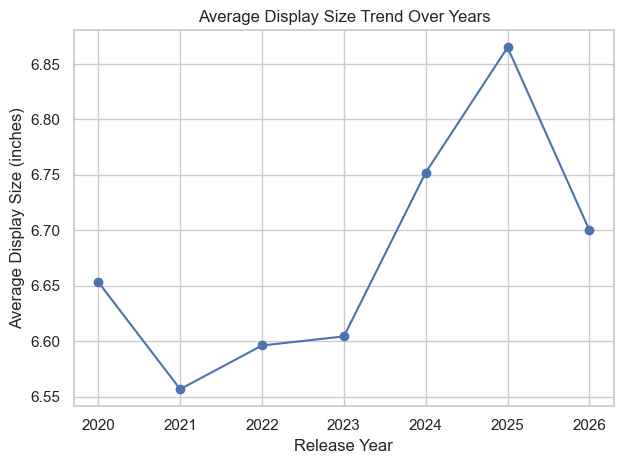

In [4]:
# ==============================
# 4. TREND ANALYSIS OVER TIME
# ==============================

# --- RAM Trend ---
ram_trend = df.groupby("release_year")["ram_raw"].mean()

plt.figure()
ram_trend.plot(marker="o")
plt.title("Average RAM Trend Over Years")
plt.xlabel("Release Year")
plt.ylabel("Average RAM (GB)")
plt.tight_layout()
plt.show()

# --- Battery Trend ---
battery_trend = df.groupby("release_year")["battery_raw"].mean()

plt.figure()
battery_trend.plot(marker="o")
plt.title("Average Battery Capacity Trend Over Years")
plt.xlabel("Release Year")
plt.ylabel("Average Battery (mAh)")
plt.tight_layout()
plt.show()

# --- Display Size Trend ---
display_trend = df.groupby("release_year")["display_raw"].mean()

plt.figure()
display_trend.plot(marker="o")
plt.title("Average Display Size Trend Over Years")
plt.xlabel("Release Year")
plt.ylabel("Average Display Size (inches)")
plt.tight_layout()
plt.show()


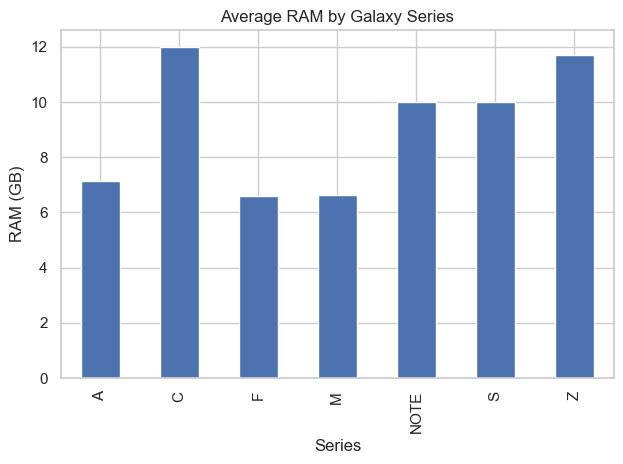

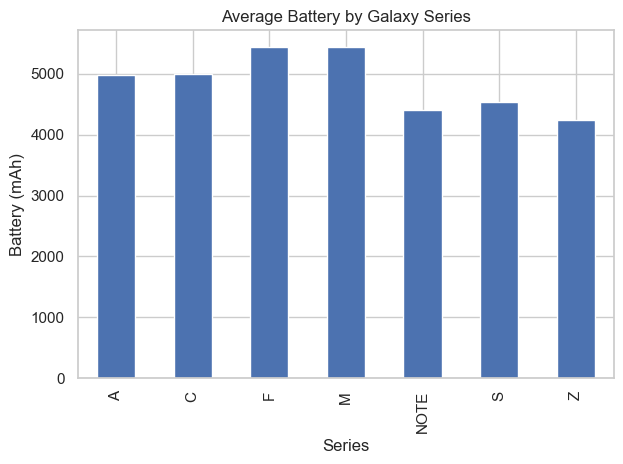

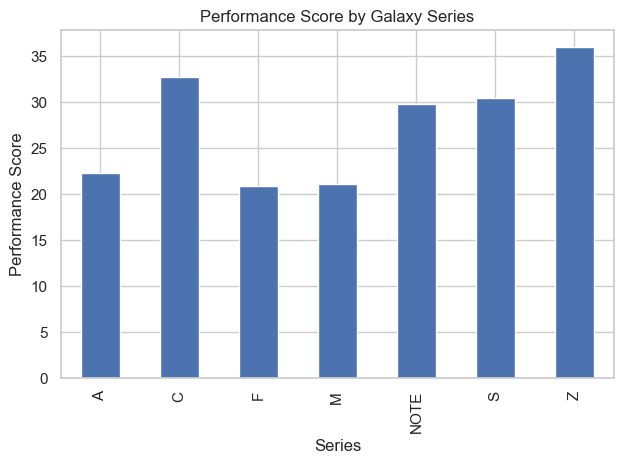

In [6]:
# ==============================
# 5. GALAXY SERIES COMPARISON
# ==============================
series_stats = df.groupby("series")[["ram_raw", "battery_raw", "performance_score"]].mean()

# --- RAM by Series ---
plt.figure()
series_stats["ram_raw"].plot(kind="bar")
plt.title("Average RAM by Galaxy Series")
plt.xlabel("Series")
plt.ylabel("RAM (GB)")
plt.tight_layout()
plt.show()

# --- Battery by Series ---
plt.figure()
series_stats["battery_raw"].plot(kind="bar")
plt.title("Average Battery by Galaxy Series")
plt.xlabel("Series")
plt.ylabel("Battery (mAh)")
plt.tight_layout()
plt.show()

# --- Performance Score by Series ---
plt.figure()
series_stats["performance_score"].plot(kind="bar")
plt.title("Performance Score by Galaxy Series")
plt.xlabel("Series")
plt.ylabel("Performance Score")
plt.tight_layout()
plt.show()


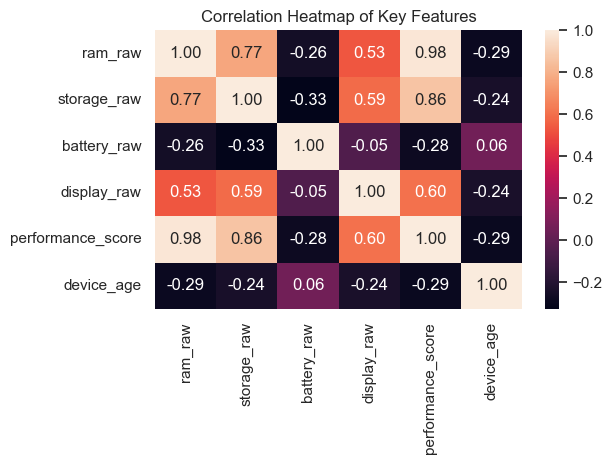

In [7]:
# ==============================
# 6. CORRELATION HEATMAP
# ==============================
numeric_cols = [
    "ram_raw",
    "storage_raw",
    "battery_raw",
    "display_raw",
    "performance_score",
    "device_age",
]

corr_matrix = df[numeric_cols].corr()

plt.figure()
sns.heatmap(corr_matrix, annot=True, fmt=".2f")
plt.title("Correlation Heatmap of Key Features")
plt.tight_layout()
plt.show()

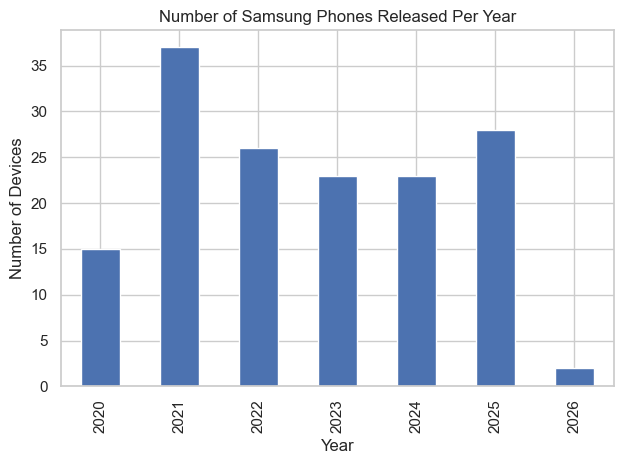

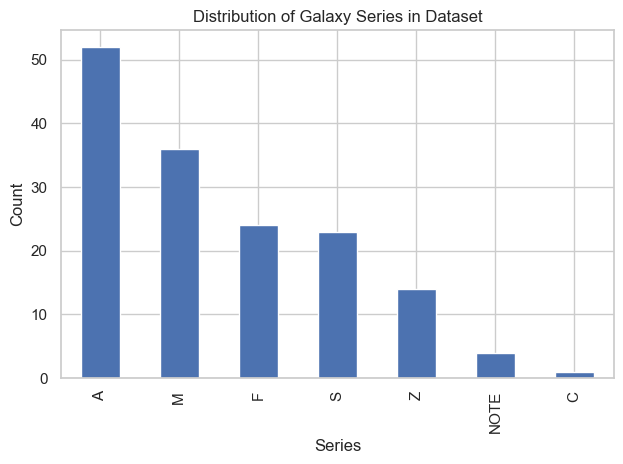

In [8]:
# ==============================
# 7. RELEASE CYCLE INSIGHTS
# ==============================
releases_per_year = df["release_year"].value_counts().sort_index()

plt.figure()
releases_per_year.plot(kind="bar")
plt.title("Number of Samsung Phones Released Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Devices")
plt.tight_layout()
plt.show()

series_distribution = df["series"].value_counts()

plt.figure()
series_distribution.plot(kind="bar")
plt.title("Distribution of Galaxy Series in Dataset")
plt.xlabel("Series")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


# ==============================
# 8. KEY FINDINGS SUMMARY
# ==============================
print("\n===== KEY INSIGHTS =====")
print("- RAM capacity shows a steady increase across release years.")
print("- Battery capacity stabilizes around the 5000 mAh range for most devices.")
print("- Mid-range series dominate total device launches.")
print("- Foldable (Z series) devices show high performance but lower release frequency.")


# ==============================
# 9. FUTURE WORK
# ==============================
print("\n===== FUTURE WORK =====")
print("- Integrate smartphone price data for price-performance analysis.")
print("- Build machine learning models to predict performance tier or price.")
print("- Compare Samsung trends with other smartphone brands.")

print("\nAnalysis complete.")
